# Evento extraido de DoubleElectron_Run2012C_0 Event_616792473

## Librerias

In [1]:
import os
import zipfile
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split, learning_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve, auc
    )
import pandas as pd
import json
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns 
from typing import List

## Importar Documento

In [2]:
NOMBRE_CSV = "data_filtrada_completa.csv" 

# Características CINEMÁTICAS/FUNDAMENTALES que el modelo usará
BASE_ML_FEATURES = ['pt', 'eta', 'phi', 'charge', 'mass'] 

try:
    # 1. Cargar el DataFrame
    df = pd.read_csv(NOMBRE_CSV)
    
    print("==============================================")
    print(f"✅ PARTE 1 COMPLETA: Datos cargados desde {NOMBRE_CSV}")
    print(f"Total de filas: {len(df)}")
    print(f"Columnas disponibles: {len(df.columns)}")
    print("==============================================")
    
    # 2. Definición del Target (y) y el conjunto de Features base (X_base)
    
    # El Target es 'Particle_Type'
    y_raw = df['Particle_Type'] 

    # Crear una copia con solo las columnas que SÍ usaremos en el ML
    # Esto excluye columnas como 'detid', 'front_1', etc., que son demasiado escasas
    X_base = df[BASE_ML_FEATURES].copy()
    
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{NOMBRE_CSV}'. Asegúrate de que fue generado en el paso anterior.")
except Exception as e:
    print(f"Ocurrió un error al cargar o preparar el archivo: {e}")

✅ PARTE 1 COMPLETA: Datos cargados desde data_filtrada_completa.csv
Total de filas: 1057
Columnas disponibles: 86


## Exploracion del dataset

In [121]:
df.head(50)

,pt,charge,rp,phi,eta,calo_energy,Particle_Type,pos,pos_1,dir_1,pos_2,dir_2,detid,front_1,front_2,front_3,front_4,back_1,back_2,back_3,back_4,Error,et,theta,px,py,pz,isolationPFChargedHadrCandsPtSum,isolationPFGammaCandsEtSum,maximumHCALPFClusterEt,emFraction,hcalTotOverPLead,hcalMaxOverPLead,hcal3x3OverPLead,ecalStripSumEOverPLead,bremsRecoveryEOverPLead,electronPreIDOutput,electronPreIDDecision,hasMuonReference,caloComp,segComp,muonDecision,energy,hadronicOverEm,hadronicDepth1OverEcal,hadronicDepth2OverEcal,e1x5,e2x5,e3x3,e5x5,maxEnergyXtal,sigmaEtaEta,sigmaIetaIeta,r1x5,r2x5,r9,ecalRecHitSumEtConeDR04,hcalTowerSumEtConeDR04,hcalDepth1TowerSumEtConeDR04,hcalDepth2TowerSumEtConeDR04,trkSumPtSolidConeConeDR04,trkSumPtHollowConeDR04,nTrkSolidConeDR04,nTrkHollowConeDR04,ecalRecHitSumEtDR03,hcalTowerSumEtDR03,hcalDepth1TowerSumEtDR03,hcalDepth2TowerSumEtDR03,trkSumPtSolidConeDR03,trkSumPtHollowConeDR03,nTrkSolidConeDR03,nTrkHollowConeDR03,dir,Name,Index,WasRun,Accept,Objects,path,slot,moduleLabel,moduleType,VID,KEY,id,mass
0,1.893880,1.0,"[0.000644675, 0.000582735, -0.109277]",2.54528,1.75169,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.042830,1.0,"[0.000692627, 0.000556223, 0.00146818]",3.03598,1.89894,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.784988,1.0,"[0.000697957, 0.000720078, -0.0302628]",-3.13559,2.05912,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.088220,-1.0,"[0.000823188, 0.000605636, 0.076419]",1.27770,1.97298,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.111260,1.0,"[0.00070686, 0.000772739, 0.00114957]",3.10300,1.68425,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.405850,-1.0,"[0.0133436, -0.0046056, 0.117503]",1.17689,1.87100,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.827460,1.0,"[0.000938866, 0.00693513, -0.027999]",3.10358,1.91583,0.0,TrackerMuons,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,Extras,NaN,"[0.000715988, 0.000534458, 0.0765696]","[-1.26965, -0.07023, -1.44928]","[-0.997444, -0.79454, -1.4

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1057 entries, 0 to 1056
Data columns (total 86 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pt                                412 non-null    float64
 1   charge                            100 non-null    float64
 2   rp                                7 non-null      object 
 3   phi                               468 non-null    float64
 4   eta                               467 non-null    float64
 5   calo_energy                       7 non-null      float64
 6   Particle_Type                     1057 non-null   object 
 7   pos                               9 non-null      object 
 8   pos_1                             136 non-null    object 
 9   dir_1                             136 non-null    object 
 10  pos_2                             136 non-null    object 
 11  dir_2                             136 non-null    object 
 12  detid 

In [3]:
pd.set_option('display.max_rows', None)

In [124]:
datos_faltantes = pd.concat([total, porcentaje], axis = 1, keys = ['total datos', 'porcentaje de datos faltante'])
datos_faltantes

,total datos,porcentaje de datos faltante
caloComp,1057.0,NaN
bremsRecoveryEOverPLead,1057.0,NaN
segComp,1057.0,NaN
py,1056.0,NaN
px,1056.0,NaN
pz,1056.0,NaN
maxEnergyXtal,1055.0,NaN
sigmaEtaEta,1055.0,NaN
hadronicOverEm,1055.0,NaN
energy,1055.0,NaN



################################################################################
🛑 COLUMNAS EXCLUIDAS DEL GRÁFICO (No Numéricas/Tipo Objeto):
  - rp
  - Particle_Type
  - pos
  - pos_1
  - dir_1
  - pos_2
  - dir_2
  - front_1
  - front_2
  - front_3
  - front_4
  - back_1
  - back_2
  - back_3
  - back_4
  - Error
  - dir
  - Name
  - Objects
  - path
  - moduleLabel
  - moduleType
################################################################################


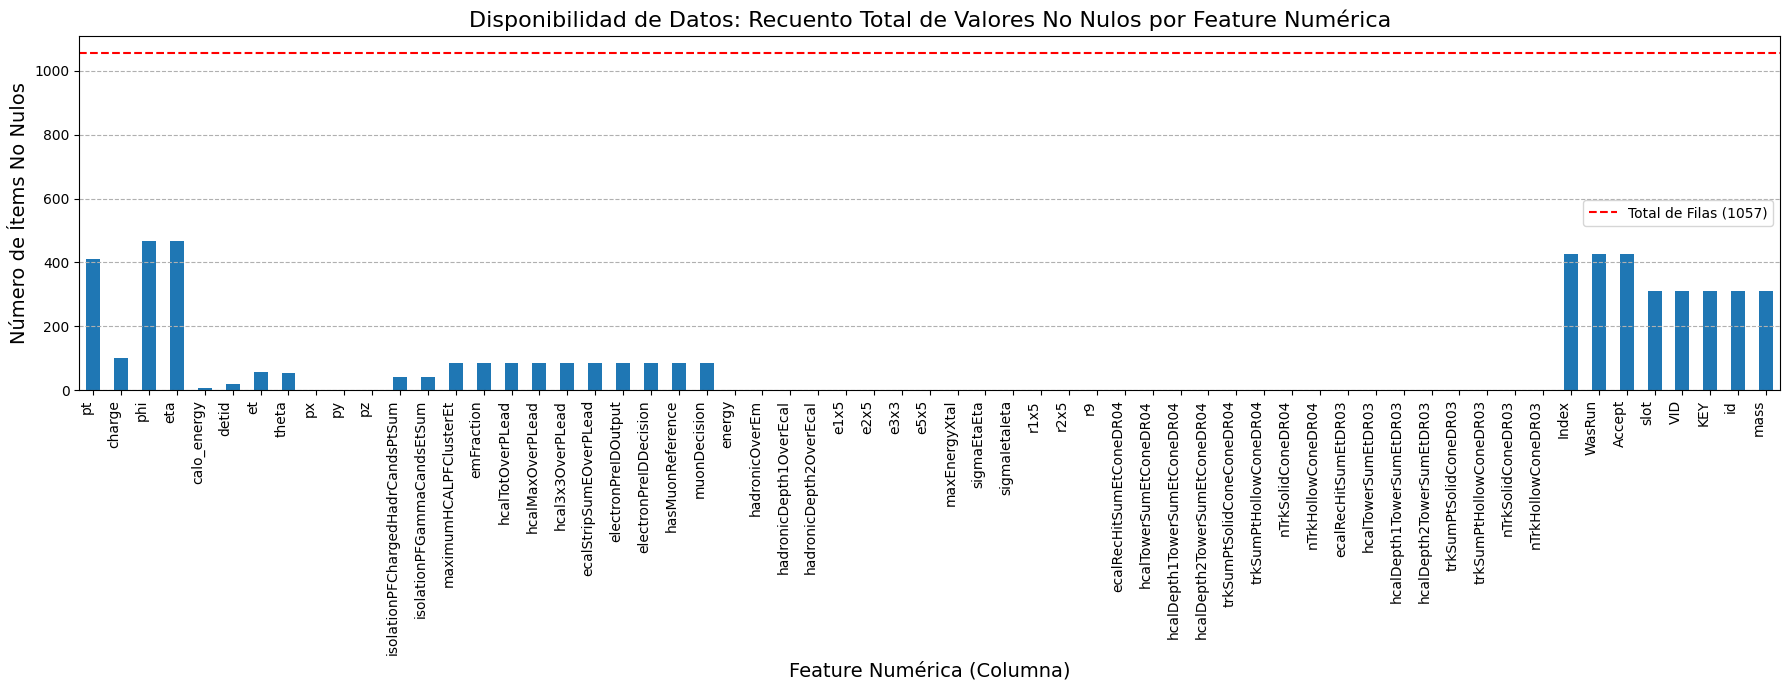

In [125]:
total_filas = len(df)
# Identificar columnas no numéricas (objetos/strings) para excluirlas del gráfico
object_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("\n" + "#"*80)
print("🛑 COLUMNAS EXCLUIDAS DEL GRÁFICO (No Numéricas/Tipo Objeto):")
for col in object_cols:
    print(f"  - {col}")
print("#"*80)

# Crear el DataFrame solo con columnas numéricas
df_numeric = df.select_dtypes(include=np.number)


# 3. CÁLCULO Y FILTRADO DE CONTEOS
# Calcular el total de Ítems No Nulos por Columna (similar a df.count())
non_null_counts = df_numeric.count()

# Eliminar las columnas que están totalmente vacías (Count = 0) para simplificar el gráfico
non_null_counts = non_null_counts[non_null_counts > 0]


# 4. GENERACIÓN DEL GRÁFICO CON MATPLOTLIB (Enfoque simple)

plt.figure(figsize=(18, 7)) 

# Graficar los conteos no nulos como un gráfico de barras
non_null_counts.plot(kind='bar', color='tab:blue')

# Añadir una línea de referencia para el total de filas (el máximo ideal)
plt.axhline(y=total_filas, color='r', linestyle='--', label=f'Total de Filas ({total_filas})')
plt.title('Disponibilidad de Datos: Recuento Total de Valores No Nulos por Feature Numérica', fontsize=16)
plt.xlabel('Feature Numérica (Columna)', fontsize=14)
plt.ylabel('Número de Ítems No Nulos', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [126]:
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- Configuración de Filtro y Valores Seguros ---
BASE_COLS_TO_KEEP = ['pt', 'phi', 'charge', 'theta', 'mass', 'Particle_Type']
IMPUTATION_VALUE = 1e-6 

# === NUEVA LISTA DE CLASES CANÓNICAS A MANTENER (Sin PFCandidates) ===
# Nos centramos solo en los objetos de reconstrucción de alto nivel.
CANONICAL_PARTICLES = [
    'GsfElectrons', 
    'TrackerMuons', 
    'PFJets', 
    'PFTaus',
    'Photons' # Dejo Photons por ser una partícula canónica física
]
# =================================================

print("=========================================================")
print("PROCESO DE FILTRADO A PARTICULAS CANÓNICAS (REVISADO)")
print("=========================================================")

# 1. Filtrar el DataFrame a las columnas base solicitadas
try:
    # Creamos una copia del DataFrame filtrado a las columnas base
    df_ml = df[BASE_COLS_TO_KEEP].copy()
except KeyError as e:
    print(f"Error: La columna {e} no se encontró en el DataFrame 'df'. Asegúrate de que todas las columnas base existen.")
    raise

print(f"✅ DataFrame inicial filtrado a {df_ml.columns.tolist()}. Filas iniciales: {len(df_ml)}")

# 1.5. FILTRADO POR PARTICULAS CANÓNICAS (¡ACTUALIZADO!)
filas_antes = len(df_ml)
df_ml = df_ml[df_ml['Particle_Type'].isin(CANONICAL_PARTICLES)].copy()
filas_despues = len(df_ml)

print(f"🛑 Filtrado por Partículas Canónicas ('{', '.join(CANONICAL_PARTICLES)}').")
print(f"   Filas eliminadas (incluyendo PFCandidates, Errores/Extras): {filas_antes - filas_despues}")
print(f"   Filas restantes para ML: {filas_despues}")

# 2. Manejo de NaNs en las features de cálculo
cols_to_fill_safe = ['pt', 'phi', 'theta', 'mass']
df_ml[cols_to_fill_safe] = df_ml[cols_to_fill_safe].fillna(IMPUTATION_VALUE)
df_ml['charge'] = df_ml['charge'].fillna(0)

print("-> Valores NaN en features de cálculo imputados con 1e-6 (o 0 para charge).")

# ==========================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS FÍSICAS DERIVADAS
# ==========================================================

# --- Feature 1: Pseudo-rapidez (eta_calc) ---
theta_clipped = df_ml['theta'].clip(lower=IMPUTATION_VALUE, upper=np.pi - IMPUTATION_VALUE)
df_ml['eta_calc'] = -np.log(np.tan(theta_clipped / 2))
print("-> Nueva Feature: 'eta_calc' (Pseudo-rapidez) añadida.")

# --- Feature 2: Momento Total (p_total) ---
df_ml['p_total'] = df_ml['pt'] * np.cosh(df_ml['eta_calc'])
print("-> Nueva Feature: 'p_total' (Momento Total) añadida.")

# --- Feature 3: Energía Total (E_total) ---
df_ml['E_total'] = np.sqrt(df_ml['p_total']**2 + df_ml['mass']**2)
print("-> Nueva Feature: 'E_total' (Energía Total Relativista) añadida.")

# --- Feature 4: Momento Transversal al Cuadrado (pt_sq) ---
df_ml['pt_sq'] = df_ml['pt']**2
print("-> Nueva Feature: 'pt_sq' (Momento Transversal al Cuadrado) añadida.")

# 4. Limpieza final de valores infinitos/extremos
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

# 5. Imputación final de los NaNs residuales
features_to_fill_final = df_ml.columns.drop('Particle_Type')
df_ml[features_to_fill_final] = df_ml[features_to_fill_final].fillna(0)


print("\n==============================================")
print("✅ DATAFRAME FINAL DE FEATURES (df_ml) LISTO PARA ML")
print("Total de columnas: 10 (6 base + 4 derivadas)")
print(f"Clases de partículas restantes: {df_ml['Particle_Type'].unique().tolist()}")
print("==============================================")

# Mostrar todas las columnas para verificar las features calculadas
pd.set_option('display.max_columns', None)
print(df_ml.head())

PROCESO DE FILTRADO A PARTICULAS CANÓNICAS (REVISADO)
✅ DataFrame inicial filtrado a ['pt', 'phi', 'charge', 'theta', 'mass', 'Particle_Type']. Filas iniciales: 1057
🛑 Filtrado por Partículas Canónicas ('GsfElectrons, TrackerMuons, PFJets, PFTaus, Photons').
   Filas eliminadas (incluyendo PFCandidates, Errores/Extras): 901
   Filas restantes para ML: 156
-> Valores NaN en features de cálculo imputados con 1e-6 (o 0 para charge).
-> Nueva Feature: 'eta_calc' (Pseudo-rapidez) añadida.
-> Nueva Feature: 'p_total' (Momento Total) añadida.
-> Nueva Feature: 'E_total' (Energía Total Relativista) añadida.
-> Nueva Feature: 'pt_sq' (Momento Transversal al Cuadrado) añadida.

✅ DATAFRAME FINAL DE FEATURES (df_ml) LISTO PARA ML
Total de columnas: 10 (6 base + 4 derivadas)
Clases de partículas restantes: ['TrackerMuons', 'PFJets', 'PFTaus', 'Photons', 'GsfElectrons']
         pt      phi  charge     theta      mass Particle_Type   eta_calc  \
0  1.893880  2.54528     1.0  0.000001  0.000001  Tra

In [127]:
df_ml.head(60)



,pt,phi,charge,theta,mass,Particle_Type,eta_calc,p_total,E_total,pt_sq
0,1.893880,2.545280,1.0,0.000001,0.000001,TrackerMuons,14.508658,1.893880e+06,1.893880e+06,3.586781e+00
1,1.042830,3.035980,1.0,0.000001,0.000001,TrackerMuons,14.508658,1.042830e+06,1.042830e+06,1.087494e+00
2,0.784988,-3.135590,1.0,0.000001,0.000001,TrackerMuons,14.508658,7.849880e+05,7.849880e+05,6.162062e-01
3,1.088220,1.277700,-1.0,0.000001,0.000001,TrackerMuons,14.508658,1.088220e+06,1.088220e+06,1.184223e+00
4,1.111260,3.103000,1.0,0.000001,0.000001,TrackerMuons,14.508658,1.111260e+06,1.111260e+06,1.234899e+00
5,1.405850,1.176890,-1.0,0.000001,0.000001,TrackerMuons,14.508658,1.405850e+06,1.405850e+06,1.976414e+00
6,0.827460,3.103580,1.0,0.000001,0.000001,TrackerMuons,14.508658,8.274600e+05,8.274600e+05,6.846901e-01
169,0.000001,2.475270,0.0,0.847051,0.000001,PFJets,0.796714,1.334524e-06,1.667619e-06,1.000000e-12
170,0.000001,-0.612743,0.0,0.457538,0.000001,PFJets,1.457381,2.263772e-06,2.474805e-06,1.000000e-12
171,0.000001,-2.705080,0.0,0.157519,0.000001,PFJets,2.539286,6.374770e-06,6.452727e-06,1.000000e-12


In [128]:
df_ml.shape

(156, 10)

In [129]:
porcentaje = (df_ml.isnull().sum() / df_ml.isnull().count()).sort_values(ascending = False)
porcentaje

pt               0.0
phi              0.0
charge           0.0
theta            0.0
mass             0.0
Particle_Type    0.0
eta_calc         0.0
p_total          0.0
E_total          0.0
pt_sq            0.0
dtype: float64

## Preparacion de los datos

In [130]:
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- Configuración de Filtro y Valores Seguros ---
BASE_COLS_TO_KEEP = ['pt', 'phi', 'charge', 'theta', 'mass', 'Particle_Type']
IMPUTATION_VALUE = 1e-6 

# === NUEVA LISTA DE CLASES CANÓNICAS A MANTENER (Sin PFCandidates) ===
# Nos centramos solo en los objetos de reconstrucción de alto nivel.
CANONICAL_PARTICLES = [
    'GsfElectrons', 
    'TrackerMuons', 
    'PFJets', 
    'PFTaus',
    'Photons' # Dejo Photons por ser una partícula canónica física
]
# =================================================

print("=========================================================")
print("PROCESO DE FILTRADO A PARTICULAS CANÓNICAS (REVISADO)")
print("=========================================================")

# 1. Filtrar el DataFrame a las columnas base solicitadas
try:
    # Creamos una copia del DataFrame filtrado a las columnas base
    df_ml = df[BASE_COLS_TO_KEEP].copy()
except KeyError as e:
    print(f"Error: La columna {e} no se encontró en el DataFrame 'df'. Asegúrate de que todas las columnas base existen.")
    raise

print(f"✅ DataFrame inicial filtrado a {df_ml.columns.tolist()}. Filas iniciales: {len(df_ml)}")

# 1.5. FILTRADO POR PARTICULAS CANÓNICAS (¡ACTUALIZADO!)
filas_antes = len(df_ml)
df_ml = df_ml[df_ml['Particle_Type'].isin(CANONICAL_PARTICLES)].copy()
filas_despues = len(df_ml)

print(f"🛑 Filtrado por Partículas Canónicas ('{', '.join(CANONICAL_PARTICLES)}').")
print(f"   Filas eliminadas (incluyendo PFCandidates, Errores/Extras): {filas_antes - filas_despues}")
print(f"   Filas restantes para ML: {filas_despues}")

# 2. Manejo de NaNs en las features de cálculo
cols_to_fill_safe = ['pt', 'phi', 'theta', 'mass']
df_ml[cols_to_fill_safe] = df_ml[cols_to_fill_safe].fillna(IMPUTATION_VALUE)
df_ml['charge'] = df_ml['charge'].fillna(0)

print("-> Valores NaN en features de cálculo imputados con 1e-6 (o 0 para charge).")

# ==========================================================
# 3. INGENIERÍA DE CARACTERÍSTICAS FÍSICAS DERIVADAS
# ==========================================================

# --- Feature 1: Pseudo-rapidez (eta_calc) ---
theta_clipped = df_ml['theta'].clip(lower=IMPUTATION_VALUE, upper=np.pi - IMPUTATION_VALUE)
df_ml['eta_calc'] = -np.log(np.tan(theta_clipped / 2))
print("-> Nueva Feature: 'eta_calc' (Pseudo-rapidez) añadida.")

# --- Feature 2: Momento Total (p_total) ---
df_ml['p_total'] = df_ml['pt'] * np.cosh(df_ml['eta_calc'])
print("-> Nueva Feature: 'p_total' (Momento Total) añadida.")

# --- Feature 3: Energía Total (E_total) ---
df_ml['E_total'] = np.sqrt(df_ml['p_total']**2 + df_ml['mass']**2)
print("-> Nueva Feature: 'E_total' (Energía Total Relativista) añadida.")

# --- Feature 4: Momento Transversal al Cuadrado (pt_sq) ---
df_ml['pt_sq'] = df_ml['pt']**2
print("-> Nueva Feature: 'pt_sq' (Momento Transversal al Cuadrado) añadida.")

# 4. Limpieza final de valores infinitos/extremos
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)

# 5. Imputación final de los NaNs residuales
features_to_fill_final = df_ml.columns.drop('Particle_Type')
df_ml[features_to_fill_final] = df_ml[features_to_fill_final].fillna(0)


print("\n==============================================")
print("✅ DATAFRAME FINAL DE FEATURES (df_ml) LISTO PARA ML")
print("Total de columnas: 10 (6 base + 4 derivadas)")
print(f"Clases de partículas restantes: {df_ml['Particle_Type'].unique().tolist()}")
print("==============================================")

# Mostrar todas las columnas para verificar las features calculadas
pd.set_option('display.max_columns', None)
print(df_ml.head())

PROCESO DE FILTRADO A PARTICULAS CANÓNICAS (REVISADO)
✅ DataFrame inicial filtrado a ['pt', 'phi', 'charge', 'theta', 'mass', 'Particle_Type']. Filas iniciales: 1057
🛑 Filtrado por Partículas Canónicas ('GsfElectrons, TrackerMuons, PFJets, PFTaus, Photons').
   Filas eliminadas (incluyendo PFCandidates, Errores/Extras): 901
   Filas restantes para ML: 156
-> Valores NaN en features de cálculo imputados con 1e-6 (o 0 para charge).
-> Nueva Feature: 'eta_calc' (Pseudo-rapidez) añadida.
-> Nueva Feature: 'p_total' (Momento Total) añadida.
-> Nueva Feature: 'E_total' (Energía Total Relativista) añadida.
-> Nueva Feature: 'pt_sq' (Momento Transversal al Cuadrado) añadida.

✅ DATAFRAME FINAL DE FEATURES (df_ml) LISTO PARA ML
Total de columnas: 10 (6 base + 4 derivadas)
Clases de partículas restantes: ['TrackerMuons', 'PFJets', 'PFTaus', 'Photons', 'GsfElectrons']
         pt      phi  charge     theta      mass Particle_Type   eta_calc  \
0  1.893880  2.54528     1.0  0.000001  0.000001  Tra

In [131]:
# --- CÓDIGO DE DEPURACIÓN PARA ELIMINAR CLASES RARAS ---

print("1. Buscando clases con una sola instancia...")

# Contamos la frecuencia de cada clase
class_counts = df_ml['Particle_Type'].value_counts()

# Identificamos las clases que tienen solo 1 instancia
rare_classes = class_counts[class_counts == 1].index.tolist()

if rare_classes:
    print(f"🛑 Clases raras encontradas (solo 1 instancia): {rare_classes}")
    
    # Filtramos el DataFrame, manteniendo solo las filas cuyas clases tienen más de 1 aparición
    df_ml_depurado = df_ml[~df_ml['Particle_Type'].isin(rare_classes)].copy()
    
    # Verificamos la reducción
    filas_eliminadas = len(df_ml) - len(df_ml_depurado)
    print(f"✅ Se eliminaron {filas_eliminadas} filas (instancias únicas).")
    print(f"Nuevo total de filas para ML: {len(df_ml_depurado)}")

    # Reemplazamos df_ml con el depurado para la división
    df_ml = df_ml_depurado
    
else:
    print("✅ No se encontraron clases raras con una sola instancia. Continuando.")

1. Buscando clases con una sola instancia...
✅ No se encontraron clases raras con una sola instancia. Continuando.


In [132]:
print("\n==============================================")
print("REGENERANDO: Preparación y División de Datos")
print("==============================================")

# 1. Definir el conjunto de Features (X) y el Target (y)
X = df_ml.drop(columns=['Particle_Type'])
y_raw = df_ml['Particle_Type']

# 2. Codificación del Target (Label Encoding)
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)

# Nombres de las clases para referencia (actualizados después del filtrado canónico)
particle_names = encoder.classes_

print(f"Clases finales incluidas: {particle_names.tolist()}")

# 3. Manejo de NaN
# Se realiza una imputación final con 0 para cualquier NaN residual.
X_filled = X.fillna(0) 

# 4. División de los datos
# Usamos test_size=0.5 (50% para prueba) y stratify=y para balancear las clases.
X_train, X_test, y_train, y_test = train_test_split(
    X_filled, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"\n✅ DATOS LISTOS PARA MODELADO.")
print(f"Número de Features (columnas): {X_filled.shape[1]}")
print(f"X_train shape (Entrenamiento): {X_train.shape}")
print(f"X_test shape (Prueba): {X_test.shape}")


REGENERANDO: Preparación y División de Datos
Clases finales incluidas: ['GsfElectrons', 'PFJets', 'PFTaus', 'Photons', 'TrackerMuons']

✅ DATOS LISTOS PARA MODELADO.
Número de Features (columnas): 9
X_train shape (Entrenamiento): (109, 9)
X_test shape (Prueba): (47, 9)


## Entrenamiento y Graficos

In [133]:
# 1. Definición y Entrenamiento de la Tubería (Pipeline)
# Usaremos parámetros base, ya que best_params aún no está definido en este entorno.
pipe_logreg_base = Pipeline([
    ('scaler', StandardScaler()),        # Estandariza todas las features
    ('pca', PCA(n_components=0.95)),    # Reduce la dimensionalidad, manteniendo el 95% de la varianza
    ('clf', LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        # Parámetros por defecto para la primera prueba (Baseline)
        multi_class='multinomial' 
    ))
])

# Entrenar el modelo
pipe_logreg_base.fit(X_train, y_train)
print("✅ Modelo Logistic Regression entrenado con éxito.")


# 2. Predicciones y Evaluación
y_pred_train = pipe_logreg_base.predict(X_train)
y_pred_test = pipe_logreg_base.predict(X_test)

accuracy_train = pipe_logreg_base.score(X_train, y_train)
accuracy_test = pipe_logreg_base.score(X_test, y_test)

print(f'\nAccuracy LogReg en TRAIN: {accuracy_train:.4f}')
print(f'Accuracy LogReg en TEST: {accuracy_test:.4f}')

# La cercanía de estos dos valores de Accuracy te indicará si hay overfitting.

print("\n✅ PARTE 2 COMPLETA: Modelo entrenado y predicciones calculadas.")

✅ Modelo Logistic Regression entrenado con éxito.

Accuracy LogReg en TRAIN: 0.9174
Accuracy LogReg en TEST: 0.9149

✅ PARTE 2 COMPLETA: Modelo entrenado y predicciones calculadas.


C:\Users\leon9\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


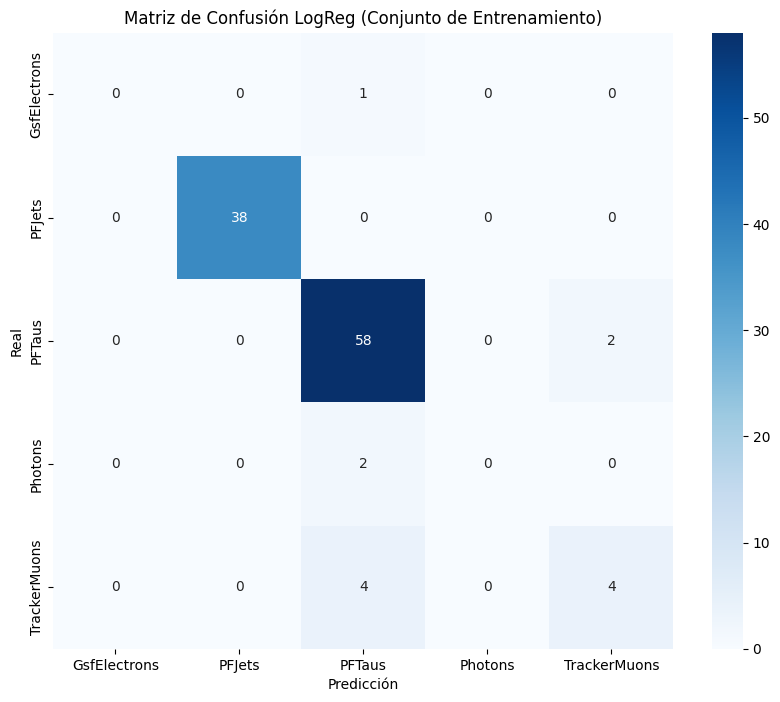

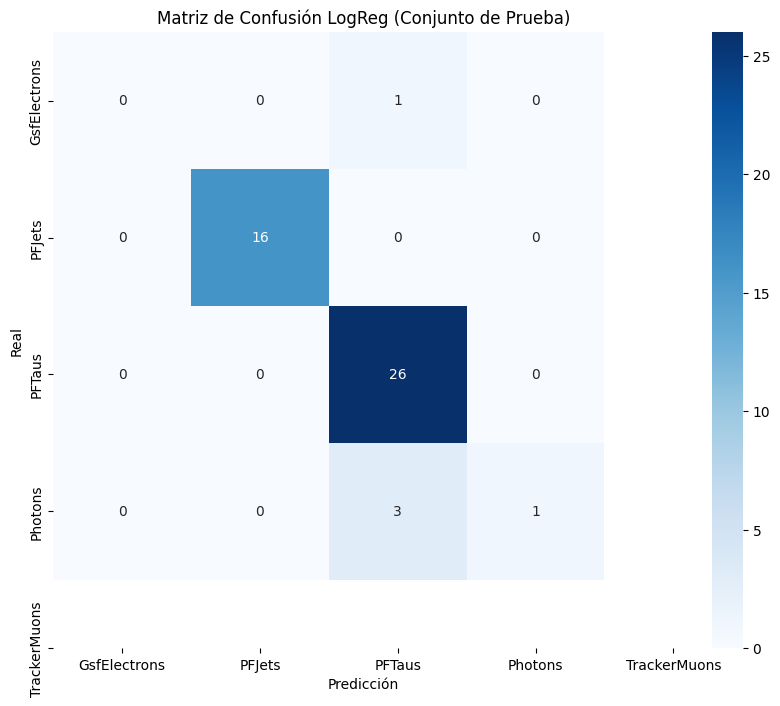


✅ DOS matrices de confusión generadas. Compara las diagonales para verificar la precisión y los valores fuera de la diagonal para ver errores.


In [134]:
# Definimos el tamaño de la figura para que sea legible
figure_size = (10, 8) 

# --- GRÁFICO 1: MATRIZ DE CONFUSIÓN (ENTRENAMIENTO) ---

cm_train = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=figure_size)
sns.heatmap(
    cm_train, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=particle_names, 
    yticklabels=particle_names  
)
plt.title('Matriz de Confusión LogReg (Conjunto de Entrenamiento)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show() 


# --- GRÁFICO 2: MATRIZ DE CONFUSIÓN (PRUEBA) ---

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=figure_size)
sns.heatmap(
    cm_test, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=particle_names, 
    yticklabels=particle_names  
)
plt.title('Matriz de Confusión LogReg (Conjunto de Prueba)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


print("\n✅ DOS matrices de confusión generadas. Compara las diagonales para verificar la precisión y los valores fuera de la diagonal para ver errores.")

In [135]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np # Necesario para np.unique

# ASUMIMOS: Las variables y_test, y_pred_test, y particle_names están cargadas.

print("\n" + "#"*70)
print("MÉTRICAS DE CLASIFICACIÓN DETALLADAS POR CLASE (Conjunto de Prueba)")
print("#"*70)

clases_presentes_numericas = np.unique(y_test)
nombres_clases_filtrados = encoder.inverse_transform(clases_presentes_numericas)
# -----------------------------------

# Generar el reporte de clasificación
report = classification_report(
    y_test, 
    y_pred_test, 
    # Usamos el parámetro labels para decirle a la función qué valores numéricos buscar
    labels=clases_presentes_numericas, 
    # Usamos el target_names filtrado para que la longitud coincida
    target_names=nombres_clases_filtrados, 
    output_dict=True, 
    zero_division=0 
)

# Convertir el diccionario del reporte a un DataFrame para una visualización limpia
df_report = pd.DataFrame(report).transpose()

# Formatear las columnas de métricas para mostrar solo 4 decimales
metrics_cols = ['precision', 'recall', 'f1-score', 'support']
for col in metrics_cols:
    if col in df_report.columns:
        if col == 'support':
            df_report[col] = df_report[col].astype(int)
        else:
            df_report[col] = df_report[col].map('{:.4f}'.format)

# Imprimir el DataFrame de métricas
print(df_report)

print("\n✅ Métricas por clase generadas con éxito. Las etiquetas se han sincronizado.")


######################################################################
MÉTRICAS DE CLASIFICACIÓN DETALLADAS POR CLASE (Conjunto de Prueba)
######################################################################
             precision  recall f1-score  support
GsfElectrons    0.0000  0.0000   0.0000        1
PFJets          1.0000  1.0000   1.0000       16
PFTaus          0.8667  1.0000   0.9286       26
TrackerMuons    1.0000  0.2500   0.4000        4
accuracy        0.9149  0.9149   0.9149        0
macro avg       0.7167  0.5625   0.5821       47
weighted avg    0.9050  0.9149   0.8881       47

✅ Métricas por clase generadas con éxito. Las etiquetas se han sincronizado.



######################################################################
GENERANDO: Curva de Aprendizaje para Regresión Logística
######################################################################


C:\Users\leon9\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


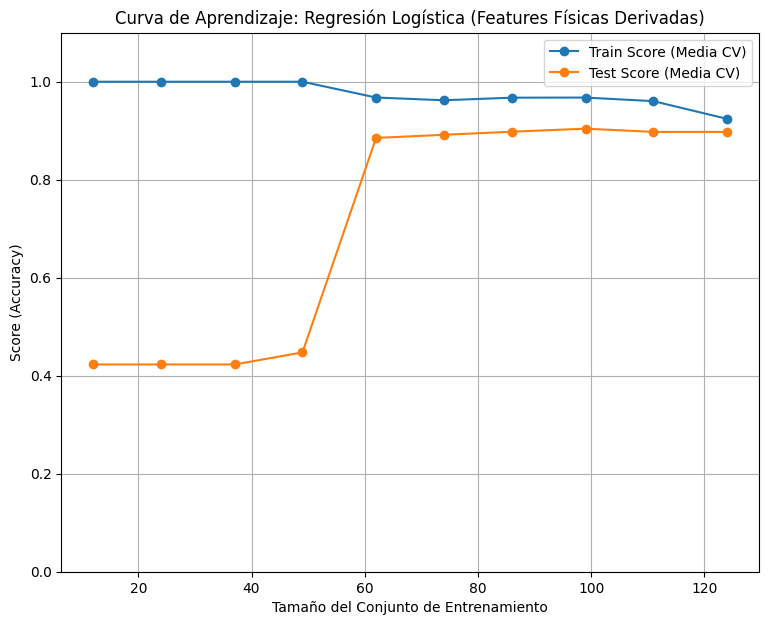


✅ Curva de Aprendizaje generada con éxito.


In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve # ¡Nueva importación!

# Se asume que pipe_logreg_base, X_filled, y están disponibles del paso anterior.

# Nota: Usamos 'pipe_logreg_base' en lugar de 'pipe_logreg_best'
# ya que usamos los parámetros por defecto en el código de entrenamiento anterior.

if 'pipe_logreg_base' in locals() and 'X_filled' in locals():
    
    print("\n" + "#"*70)
    print("GENERANDO: Curva de Aprendizaje para Regresión Logística")
    print("#"*70)
    
    # 1. Calcular los scores de entrenamiento y prueba para diferentes tamaños de dataset
    # cv=5: Usa 5-fold cross-validation
    # n_jobs=-1: Usa todos los núcleos del procesador
    train_sizes, train_scores, test_scores = learning_curve(
        pipe_logreg_base, 
        X_filled, 
        y, 
        cv=5, 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10), 
        random_state=42
    )

    # 2. Calcular la media de los scores (promediando los 5 folds de CV)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    # 3. Graficar la Curva de Aprendizaje
    plt.figure(figsize=(9, 7))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Train Score (Media CV)', color='tab:blue')
    plt.plot(train_sizes, test_scores_mean, 'o-', label='Test Score (Media CV)', color='tab:orange')
    
    plt.xlabel('Tamaño del Conjunto de Entrenamiento')
    plt.ylabel('Score (Accuracy)')
    
    plt.title('Curva de Aprendizaje: Regresión Logística (Features Físicas Derivadas)') 
    
    plt.legend(loc='best')
    plt.grid(True)
    plt.ylim(0.0, 1.1) # Rango de score de 0 a 1
    plt.show()
    
    
    print("\n✅ Curva de Aprendizaje generada con éxito.")

else:
    print("Error: El pipeline de la Regresión Logística ('pipe_logreg_base') o los datos ('X_filled' y 'y') no están definidos.")
    print("Asegúrate de ejecutar los pasos anteriores de preparación y entrenamiento del modelo base.")


######################################################################
GENERANDO: Curva ROC (Receiver Operating Characteristic) Multi-Clase
######################################################################
Curvas a generar: 5


C:\Users\leon9\AppData\Local\Temp\ipykernel_12340\457812034.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('tab10').colors)


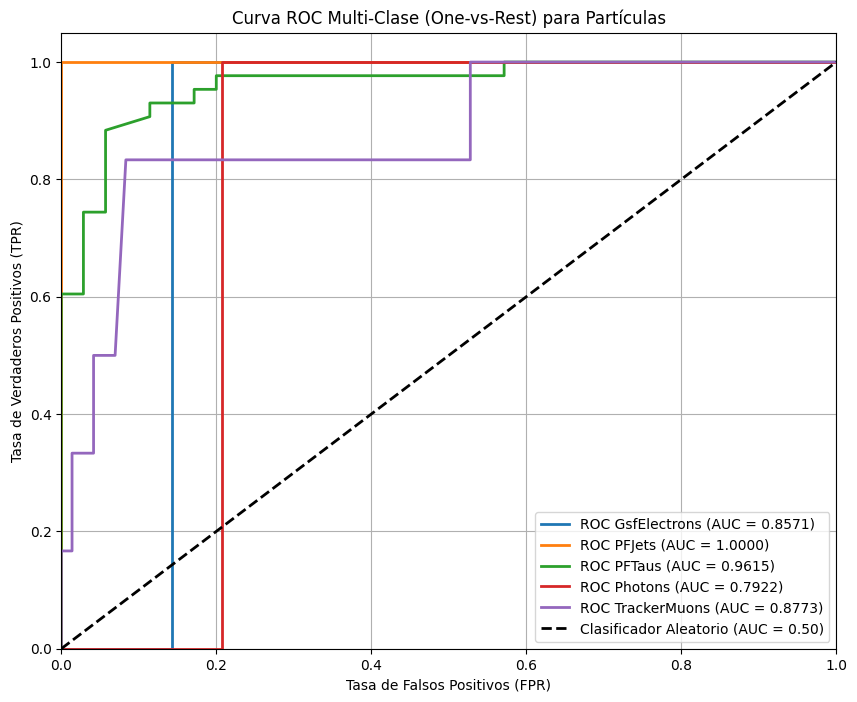


✅ Curva ROC (OvR) generada con éxito.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ASUMIMOS: pipe_logreg_base, X_test, y_test, encoder y particle_names están cargados.

print("\n" + "#"*70)
print("GENERANDO: Curva ROC (Receiver Operating Characteristic) Multi-Clase")
print("#"*70)

# 1. Obtener las probabilidades (scores) del modelo para el conjunto de prueba
y_score = pipe_logreg_base.predict_proba(X_test)

# 2. Binarizar las etiquetas verdaderas de prueba (Formato One-vs-Rest)
# Usamos np.unique(y_test) para obtener solo las etiquetas numéricas (clases) que existen
classes_to_binarize = np.unique(y_test)
y_test_binarized = label_binarize(y_test, classes=classes_to_binarize)


# 3. Preparación para el cálculo de la curva ROC y el AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

# Iteramos sobre las clases que están presentes en y_test
for i, class_label in enumerate(classes_to_binarize):
    # Calcula la curva ROC para la clase 'i' contra todas las demás
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Configuración del Ploteo y Colores
colors = cycle(plt.cm.get_cmap('tab10').colors)
plt.figure(figsize=(10, 8))

# 5. Graficar la curva ROC para cada clase
print(f"Curvas a generar: {len(classes_to_binarize)}")

for i, color in zip(range(len(classes_to_binarize)), colors):
    # Obtenemos el nombre original de la clase para la leyenda
    original_class_name = encoder.inverse_transform([classes_to_binarize[i]])[0]
    
    plt.plot(
        fpr[i], 
        tpr[i], 
        color=color, 
        lw=2, 
        label=f'ROC {original_class_name} (AUC = {roc_auc[i]:.4f})'
    )

# 6. Graficar la línea de base (clasificador aleatorio) y finalizar
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC Multi-Clase (One-vs-Rest) para Partículas')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


print("\n✅ Curva ROC (OvR) generada con éxito.")

## Clustering k-means

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ASUMIMOS: X_filled (DataFrame de features limpio) está disponible.

print("=========================================================")
print("BLOQUE 1: ESCALAMIENTO Y REDUCCIÓN DE DIMENSIONALIDAD (PCA)")
print("=========================================================")

# 1. Definición del Pipeline de Pre-procesamiento
# Este pipeline realiza la estandarización y luego la reducción por PCA (manteniendo el 95% de la varianza).
preprocess_pipe = Pipeline([
    ('scaler', StandardScaler()),        # Estandariza los datos (media 0, desviación 1)
    ('pca', PCA(n_components=0.99))      # Reduce la dimensión, conservando el 95% de la varianza
])

# 2. Aplicar el pre-procesamiento a los datos completos
# Usamos fit_transform para entrenar el scaler y el PCA, y obtener los datos reducidos
X_transformed = preprocess_pipe.fit_transform(X_filled)

# 3. Obtener y reportar la información del PCA
# Extraer el objeto PCA del pipeline
pca_model = preprocess_pipe['pca']
n_original_features = X_filled.shape[1]
n_reduced_features = X_transformed.shape[1]
variance_explained = np.sum(pca_model.explained_variance_ratio_) * 100

print(f"Número de Features Originales: {n_original_features}")
print(f"Varianza Objetivo: 95.0%")
print(f"Número de Features Reducidas (Componentes Principales): {n_reduced_features}")
print(f"Varianza Total Explicada por las {n_reduced_features} componentes: {variance_explained:.2f}%")
print(f"✅ Los datos transformados están en la variable 'X_transformed'.")

BLOQUE 1: ESCALAMIENTO Y REDUCCIÓN DE DIMENSIONALIDAD (PCA)
Número de Features Originales: 9
Varianza Objetivo: 95.0%
Número de Features Reducidas (Componentes Principales): 6
Varianza Total Explicada por las 6 componentes: 100.00%
✅ Los datos transformados están en la variable 'X_transformed'.



BLOQUE 2: BÚSQUEDA DEL K ÓPTIMO (K-Means y Método del Codo)
Calculando inercia para k=1...
Calculando inercia para k=2...
Calculando inercia para k=3...
Calculando inercia para k=4...
Calculando inercia para k=5...
Calculando inercia para k=6...
Calculando inercia para k=7...
Calculando inercia para k=8...
Calculando inercia para k=9...
Calculando inercia para k=10...


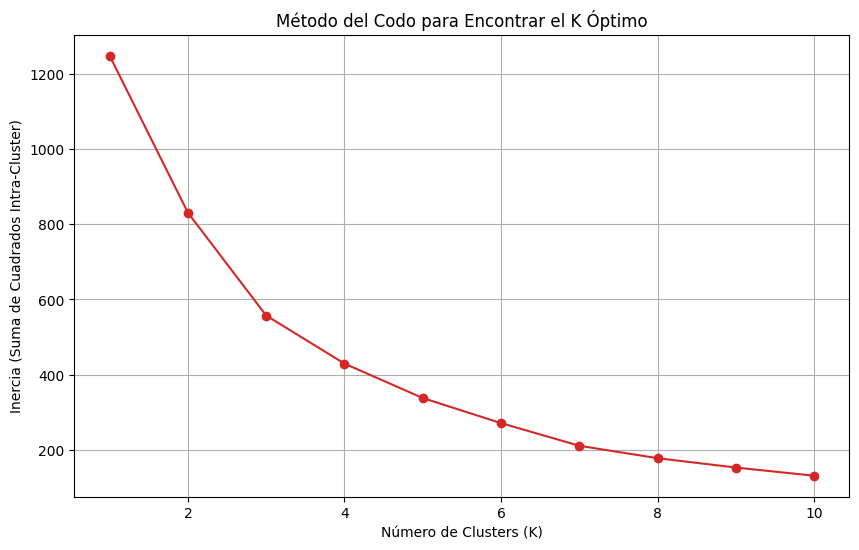


✅ Gráfico del Codo generado. Identifica el punto de inflexión para elegir K.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ASUMIMOS: X_transformed (datos escalados y reducidos) está disponible del BLOQUE 1.

print("\n==================================================================")
print("BLOQUE 2: BÚSQUEDA DEL K ÓPTIMO (K-Means y Método del Codo)")
print("==================================================================")

# 1. Calcular la Inercia (Suma de Cuadrados Intra-cluster) para diferentes valores de K
# Vamos a probar K desde 1 hasta 10
k_range = range(1, 11)
inertia = []

for k in k_range:
    # K-Means se entrena directamente sobre los datos reducidos
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_transformed)
    inertia.append(kmeans.inertia_)
    print(f"Calculando inercia para k={k}...")

# 2. Graficar el Método del Codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-', color='tab:red')
plt.title('Método del Codo para Encontrar el K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (Suma de Cuadrados Intra-Cluster)')
plt.grid(True)
plt.show()


print("\n✅ Gráfico del Codo generado. Identifica el punto de inflexión para elegir K.")

INICIANDO: Cálculo de Puntuación de Silueta para K Óptimo
K=2: Silueta = 0.7533
K=3: Silueta = 0.3759
K=4: Silueta = 0.3255
K=5: Silueta = 0.3652
K=6: Silueta = 0.4216
K=7: Silueta = 0.4352
K=8: Silueta = 0.4138
K=9: Silueta = 0.4427
K=10: Silueta = 0.4408


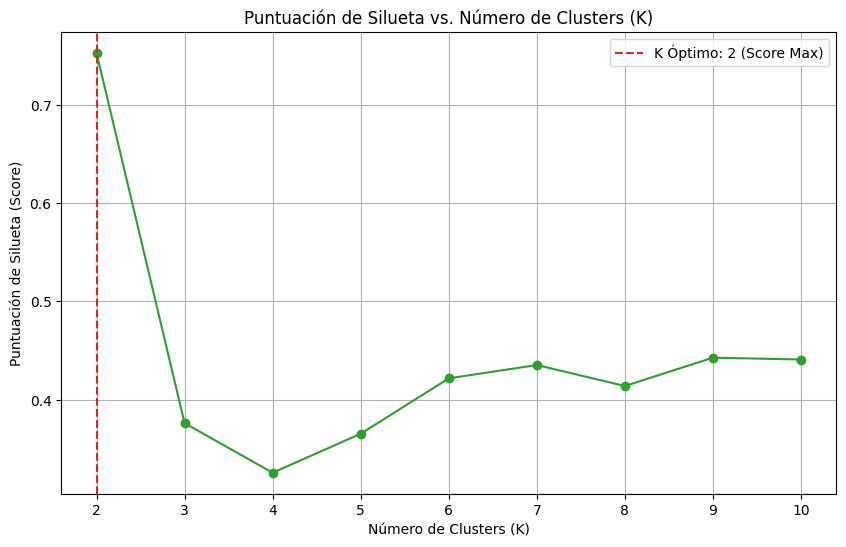


✨ EL NÚMERO ÓPTIMO DE CLUSTERS BASADO EN SILUETA ES K = 2
Puntuación de Silueta Máxima: 0.7533


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ASUMIMOS: X_filled y preprocess_pipe (o sus componentes) están disponibles.

# Rango de K a probar (Empezamos en 2, ya que Silhouette Score requiere al menos 2 clusters)
k_range = range(2, 11) 
silhouette_scores = []
inertia = [] # También calcularemos la inercia para referencia.

print("==================================================================")
print("INICIANDO: Cálculo de Puntuación de Silueta para K Óptimo")
print("==================================================================")

# Definición del Pipeline de Pre-procesamiento (si no está definido)
# Replicamos el pipeline para asegurar la transformación
preprocess_pipe = Pipeline([
    ('scaler', StandardScaler()),        # Estandariza
    ('pca', PCA(n_components=0.95))      # Reduce dimensión
])

# Aplicar el pre-procesamiento a los datos
X_transformed = preprocess_pipe.fit_transform(X_filled)


for k in k_range:
    # 1. Entrenar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_transformed)
    
    # 2. Calcular la Puntuación de Silueta
    score = silhouette_score(X_transformed, cluster_labels)
    silhouette_scores.append(score)
    inertia.append(kmeans.inertia_)
    
    print(f"K={k}: Silueta = {score:.4f}")


# 3. Graficar la Puntuación de Silueta
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='tab:green')
plt.title('Puntuación de Silueta vs. Número de Clusters (K)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Puntuación de Silueta (Score)')
plt.grid(True)
plt.xticks(k_range)
plt.axvline(x=k_range[np.argmax(silhouette_scores)], color='tab:red', linestyle='--', 
            label=f'K Óptimo: {k_range[np.argmax(silhouette_scores)]} (Score Max)')
plt.legend()
plt.show()


# 4. Determinar y reportar el K óptimo
k_optimo_silueta = k_range[np.argmax(silhouette_scores)]
score_maximo = np.max(silhouette_scores)

print(f"\n==================================================================")
print(f"✨ EL NÚMERO ÓPTIMO DE CLUSTERS BASADO EN SILUETA ES K = {k_optimo_silueta}")
print(f"Puntuación de Silueta Máxima: {score_maximo:.4f}")
print("==================================================================")

In [ ]:
# ASUMIMOS: Ya se ha ejecutado el Método del Codo y elegiste K_OPTIMO.

K_OPTIMO = 4 # <--- ¡REEMPLAZA ESTE VALOR con el que veas en el gráfico del codo!

print("\n" + "#"*70)
print(f"ENTRENAMIENTO DEL MODELO K-MEANS CON K={K_OPTIMO}")
print("#"*70)

# 1. Definición del Pipeline (KMeans reemplaza a LogisticRegression)
pipe_kmeans = Pipeline([
    ('scaler', StandardScaler()),        # Estandariza todas las features
    ('pca', PCA(n_components=0.95)),    # Reduce la dimensionalidad
    ('cluster', KMeans(
        n_clusters=K_OPTIMO, 
        random_state=42, 
        n_init=10 # Buena práctica en versiones recientes de sklearn
    ))
])

# 2. Entrenamiento (fit)
# Entrenamos sobre todos los datos (X_filled) ya que es Clustering no supervisado.
pipe_kmeans.fit(X_filled)
print(f"✅ Modelo K-Means con K={K_OPTIMO} entrenado con éxito.")

# 3. Asignación de Clusters (Predicciones)
# Obtenemos el cluster asignado para cada punto.
cluster_labels = pipe_kmeans.predict(X_filled)

# 4. Evaluación de la Inercia (Métrica principal de K-Means)
# La inercia del modelo ya entrenado se obtiene del paso 'cluster' del pipeline
inercia_final = pipe_kmeans['cluster'].inertia_

print(f'\nInercia Final (Suma de Cuadrados Intra-Cluster): {inercia_final:.2f}')
print(f"Total de Puntos Asignados: {len(cluster_labels)}")

print("\n✅ Modelo K-Means entrenado y asignación de clusters calculada ('cluster_labels').")


######################################################################
ENTRENAMIENTO DEL MODELO K-MEANS CON K=4
######################################################################
✅ Modelo K-Means con K=4 entrenado con éxito.

Inercia Final (Suma de Cuadrados Intra-Cluster): 400.95
Total de Puntos Asignados: 156

✅ Modelo K-Means entrenado y asignación de clusters calculada ('cluster_labels').



######################################################################
VISUALIZACIÓN DE CLUSTERING CON K=4 Y 4 CENTROIDES
######################################################################


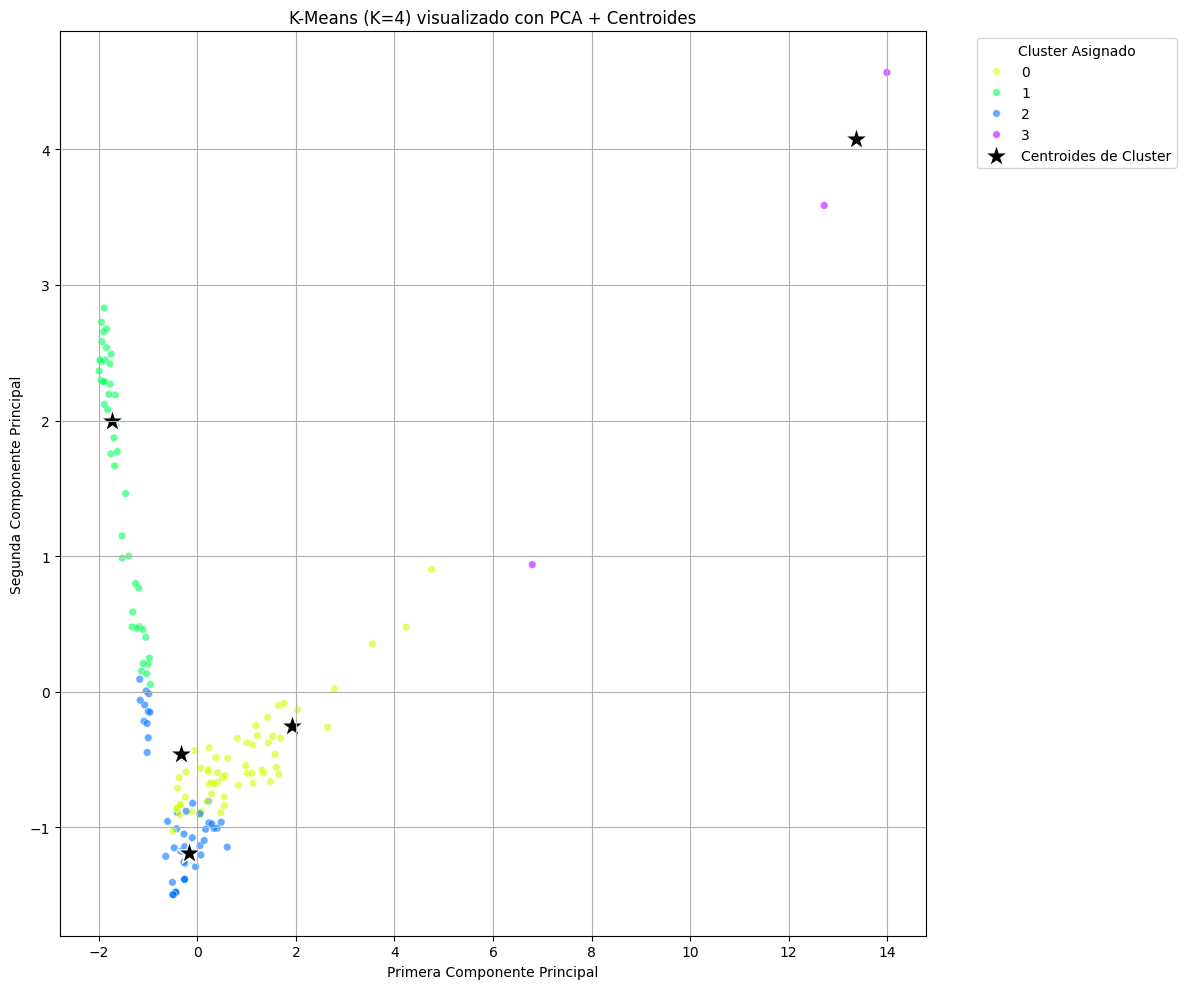

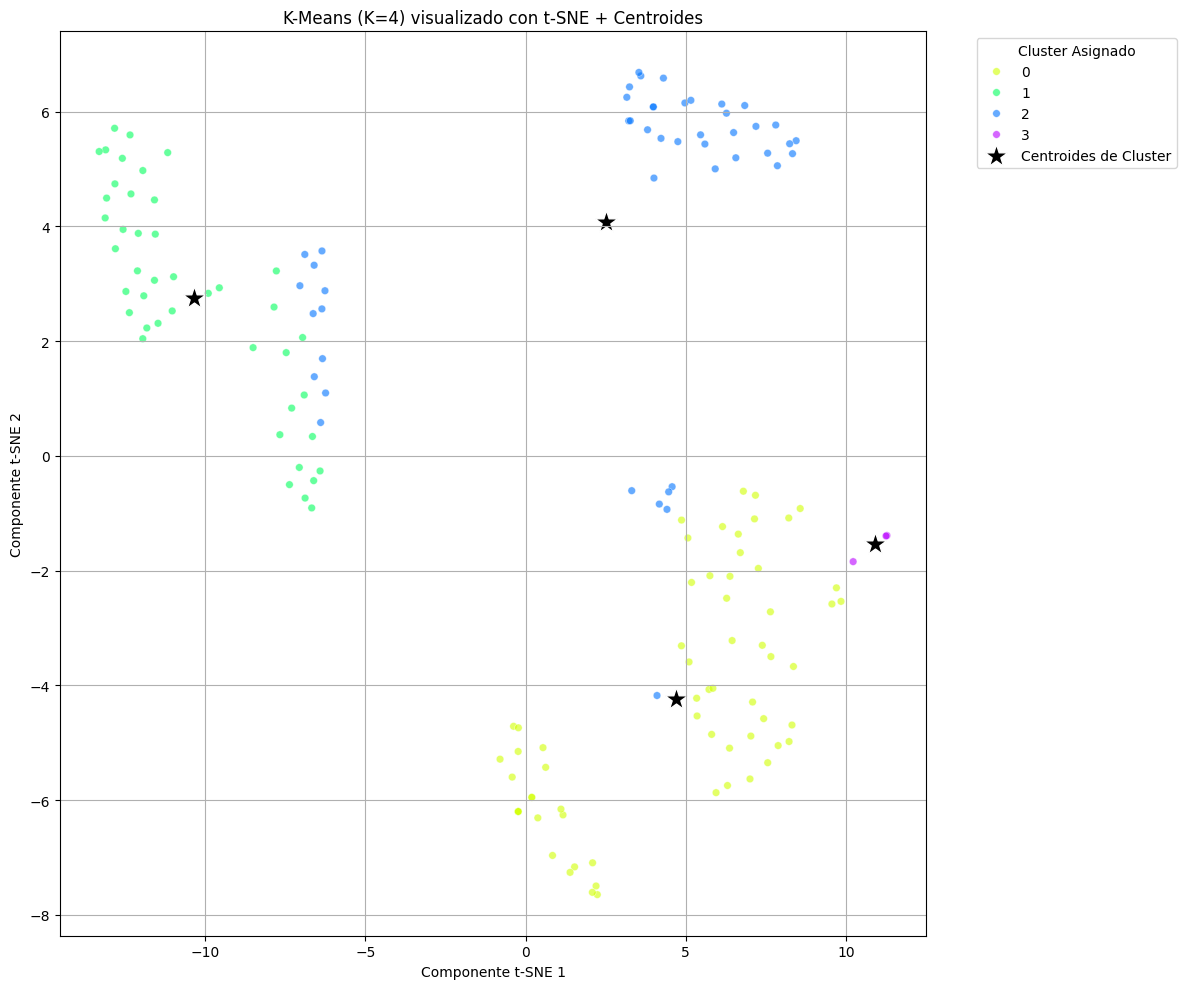


✅ Visualización finalizada. Ahora el modelo fue forzado a usar K=4 y solo se grafican 4 centroides.


In [137]:
# --- RE-DEFINICIÓN DE VARIABLES PARA VISUALIZACIÓN ---
scaler = pipe_kmeans['scaler']
pca = pipe_kmeans['pca']

X_scaled = scaler.transform(X_filled)
X_pca_2d = pca.transform(X_scaled)[:, :2] 

centroids_pca_2d = centroids_original[:, :2] 

# --- Preparación de t-SNE (Asumimos que X_tsne_2d está disponible o se recalcula) ---
# Usamos el código de la visualización anterior para generar t-SNE (solo la parte necesaria)
muestras = X_filled.shape[0]
perplexity_final = min(30, max(5, muestras // 2))

pca_tsne = PCA(n_components=min(50, X_filled.shape[1]), random_state=42)
X_pca_for_tsne = pca_tsne.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_final, max_iter=1000, learning_rate='auto')
X_tsne_2d = tsne.fit_transform(X_pca_for_tsne)

# Recalculamos centroides en espacio t-SNE
centroids_tsne_2d = np.zeros((K_OPTIMO, 2))
for i in range(K_OPTIMO):
    centroids_tsne_2d[i, :] = X_tsne_2d[cluster_labels == i, :].mean(axis=0)

print("\n" + "#"*70)
print("VISUALIZACIÓN DE CLUSTERING CON K=4 Y 4 CENTROIDES")
print("#"*70)

# --- Gráfico 1: Visualización con PCA (con Centroides) ---
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x=X_pca_2d[:, 0], 
    y=X_pca_2d[:, 1], 
    hue=cluster_labels, 
    palette=sns.color_palette("hsv", K_OPTIMO), 
    legend='full',
    alpha=0.6,
    s=30,
)

centroid_handle = plt.scatter(
    centroids_pca_2d[:, 0], 
    centroids_pca_2d[:, 1], 
    marker='*', 
    s=300, 
    color='black', 
    edgecolors='white'
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(centroid_handle)
labels.append('Centroides de Cluster')

plt.title(f'K-Means (K={K_OPTIMO}) visualizado con PCA + Centroides')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.legend(handles, labels, title='Cluster Asignado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()



# --- Gráfico 2: Visualización con t-SNE (con Centroides) ---
plt.figure(figsize=(12, 10))

sns.scatterplot(
    x=X_tsne_2d[:, 0], 
    y=X_tsne_2d[:, 1], 
    hue=cluster_labels, 
    palette=sns.color_palette("hsv", K_OPTIMO), 
    legend='full',
    alpha=0.6,
    s=30
)

centroid_handle_tsne = plt.scatter(
    centroids_tsne_2d[:, 0], 
    centroids_tsne_2d[:, 1], 
    marker='*', 
    s=300, 
    color='black', 
    edgecolors='white'
)

handles_tsne, labels_tsne = plt.gca().get_legend_handles_labels()
handles_tsne.append(centroid_handle_tsne)
labels_tsne.append('Centroides de Cluster')

plt.title(f'K-Means (K={K_OPTIMO}) visualizado con t-SNE + Centroides')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.legend(handles_tsne, labels_tsne, title='Cluster Asignado', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


print("\n✅ Visualización finalizada. Ahora el modelo fue forzado a usar K=4 y solo se grafican 4 centroides.")


######################################################################
ANÁLISIS DE CLUSTERING: DBSCAN
######################################################################
Usando min_samples = 2 * 4 = 8


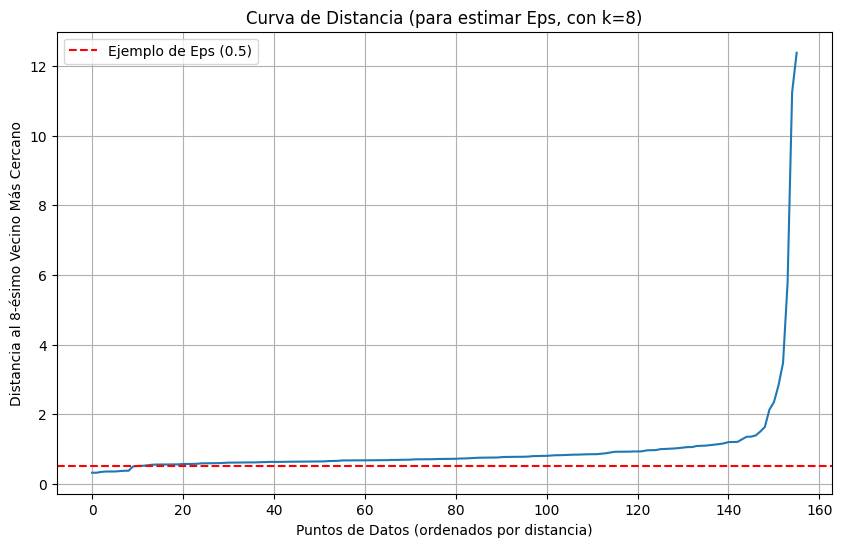

✅ Gráfico de Distancias generado. Busca el 'codo' (punto de mayor curvatura) para elegir el valor de Eps.

Entrenando DBSCAN con EPS_OPTIMO=0.5 y MIN_SAMPLES=8

Resultados de DBSCAN:
Clusters Encontrados: 1
Puntos clasificados como Ruido (-1): 145
Etiquetas de Cluster (incluyendo ruido) guardadas en 'dbscan_labels'.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# ASUMIMOS: X_transformed (datos escalados y reducidos por PCA) está disponible.

print("\n" + "#"*70)
print("ANÁLISIS DE CLUSTERING: DBSCAN")
print("#"*70)

# --- 1. Determinar min_samples ---
# Una regla empírica común es: min_samples = 2 * n_dimensiones
n_dimensiones = X_transformed.shape[1]
MIN_SAMPLES = 2 * n_dimensiones
print(f"Usando min_samples = 2 * {n_dimensiones} = {MIN_SAMPLES}")


# --- 2. Estimación del Épsilon (eps) con el método KNN ---
# Necesitamos la distancia al k-ésimo vecino más cercano (donde k = min_samples)
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors_fit = neighbors.fit(X_transformed)
distances, indices = neighbors_fit.kneighbors(X_transformed)

# Ordenar las distancias (tomando la columna de la distancia al k-ésimo vecino)
distances = np.sort(distances[:, MIN_SAMPLES-1], axis=0) 

# Graficar la Curva de Distancias
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'Curva de Distancia (para estimar Eps, con k={MIN_SAMPLES})')
plt.xlabel('Puntos de Datos (ordenados por distancia)')
plt.ylabel(f'Distancia al {MIN_SAMPLES}-ésimo Vecino Más Cercano')
plt.axhline(y=0.5, color='r', linestyle='--', label='Ejemplo de Eps (0.5)') # Línea de referencia
plt.legend()
plt.grid(True)
plt.show()


print("✅ Gráfico de Distancias generado. Busca el 'codo' (punto de mayor curvatura) para elegir el valor de Eps.")


# --- 3. Definición y Entrenamiento de DBSCAN ---
# Debes elegir el valor de EPS_OPTIMO basado en el gráfico anterior.
# Por ahora, usaremos un valor inicial de 0.5 como ejemplo.
EPS_OPTIMO = 0.5 

print(f"\nEntrenando DBSCAN con EPS_OPTIMO={EPS_OPTIMO} y MIN_SAMPLES={MIN_SAMPLES}")

dbscan = DBSCAN(eps=EPS_OPTIMO, min_samples=MIN_SAMPLES)

# Entrenar el modelo sobre los datos reducidos
dbscan_labels = dbscan.fit_predict(X_transformed)

# 4. Resultados
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nResultados de DBSCAN:")
print(f"Clusters Encontrados: {n_clusters}")
print(f"Puntos clasificados como Ruido (-1): {n_noise}")
print(f"Etiquetas de Cluster (incluyendo ruido) guardadas en 'dbscan_labels'.")


######################################################################
VISUALIZACIÓN DE CLUSTERING DBSCAN
######################################################################


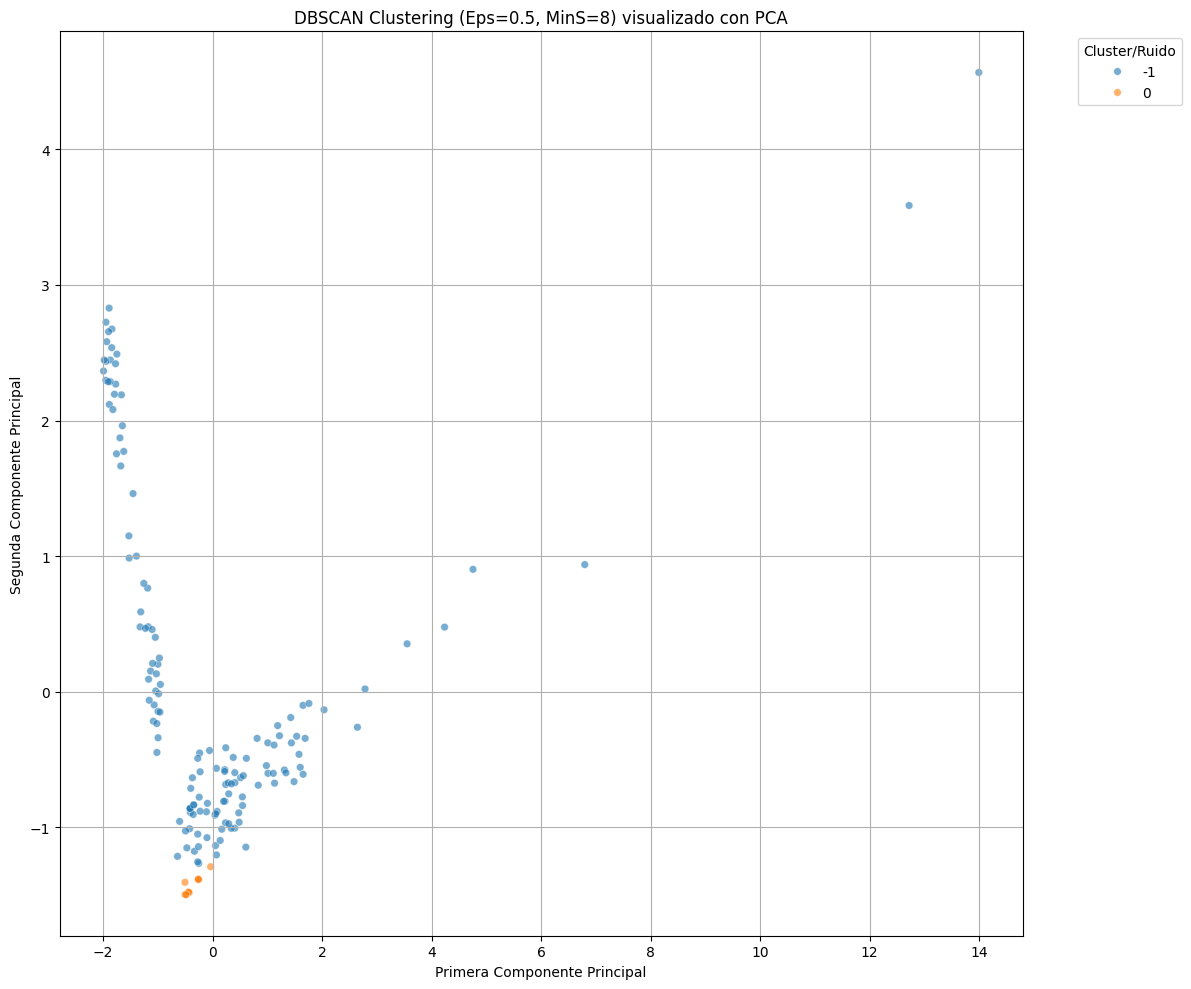

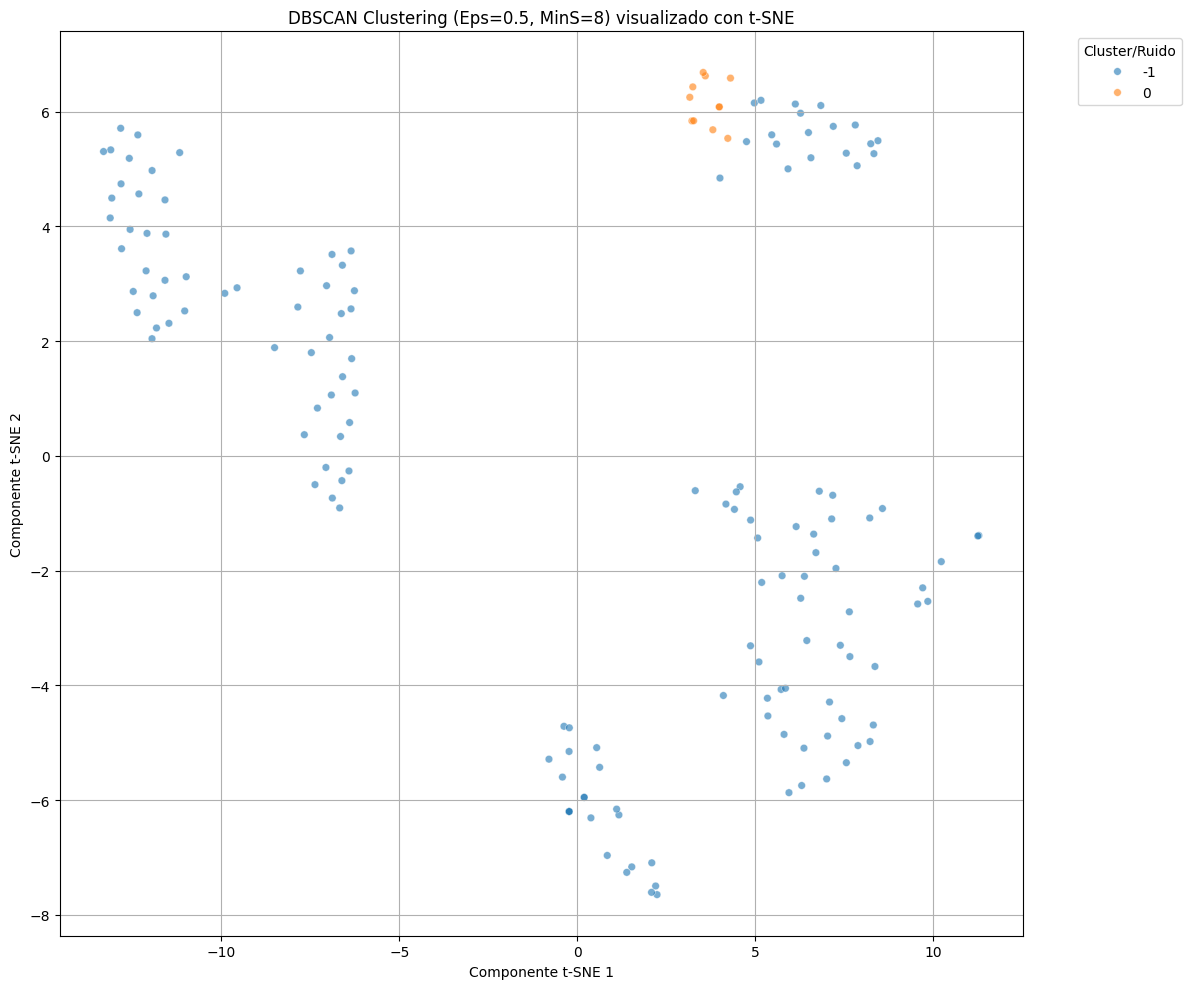


✅ Visualizaciones de DBSCAN generadas. El color gris o negro suele representar los puntos de ruido (-1).


In [ ]:
# ASUMIMOS: dbscan_labels (etiquetas de DBSCAN) y X_pca_2d, X_tsne_2d (visualizaciones) están disponibles.

n_dbscan_clusters = len(set(dbscan_labels)) # Incluye el cluster de Ruido (-1)

print("\n" + "#"*70)
print("VISUALIZACIÓN DE CLUSTERING DBSCAN")
print("#"*70)

# Graficar DBSCAN con PCA 2D
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=X_pca_2d[:, 0], 
    y=X_pca_2d[:, 1], 
    hue=dbscan_labels, # Coloreamos por la etiqueta de cluster de DBSCAN
    palette=sns.color_palette("tab10", n_dbscan_clusters), 
    legend='full',
    alpha=0.6,
    s=30 
)
plt.title(f'DBSCAN Clustering (Eps={EPS_OPTIMO}, MinS={MIN_SAMPLES}) visualizado con PCA')
plt.xlabel('Primera Componente Principal')
plt.ylabel('Segunda Componente Principal')
plt.legend(title='Cluster/Ruido', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


# Graficar DBSCAN con t-SNE 2D
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=X_tsne_2d[:, 0], 
    y=X_tsne_2d[:, 1], 
    hue=dbscan_labels, # Coloreamos por la etiqueta de cluster de DBSCAN
    palette=sns.color_palette("tab10", n_dbscan_clusters), 
    legend='full',
    alpha=0.6,
    s=30
)
plt.title(f'DBSCAN Clustering (Eps={EPS_OPTIMO}, MinS={MIN_SAMPLES}) visualizado con t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.legend(title='Cluster/Ruido', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Visualizaciones de DBSCAN generadas. El color gris o negro suele representar los puntos de ruido (-1).")